In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
path = '/Users/qianj/Library/Mobile Documents/com~apple~CloudDocs/AA_2024-2026 job/Erdos_Project'

In [3]:
df_pushed_year = pd.read_csv(f'{path}/Modeling/common_NPI_pushed_year_df_with_pca_1_scaled_type_tot_risk_covid_3.csv').drop('Unnamed: 0',axis=1)
df_origin = pd.read_csv(f'{path}/Modeling/original_year_with_type_risk_tot_risk_pca_covid_3.csv').drop('Unnamed: 0', axis=1)

In [7]:
df_train = df_pushed_year[df_pushed_year['year']<=2021].copy()
df_val = df_origin[df_origin['year']==2021].copy() # use 2021 data predict for 2022, the df_origin dataset is in original year
df_val['year']=2022
df_val['Is_Covid']=0
actual_total_y = sum(df_origin[df_origin['year']==2022]['Tot_Mdcr_Pymt_Amt'])
actual_y = df_origin[df_origin['year']==2022]['Tot_Mdcr_Pymt_Amt']
actual_total_y

106979419226.792

In [8]:
df_2022 = df_origin[df_origin['year']==2022].copy()
df_2022['year'] = 2023
actual_total_2023 = sum(df_origin[df_origin['year']==2023]['Tot_Mdcr_Pymt_Amt'])

# Preprocessing Columns

In [9]:
label_cols = ['APP_Tot_Risk','PrimaryCare_Tot_Risk','MedicalSpecialtyOther_Tot_Risk','LabPathology_Tot_Risk','PharmacyNutrition_Tot_Risk']

def label_num_to_cat(df,cols):
    for c in cols:
        df[c] = df[c].astype(int).astype('object')
    return

In [10]:
label_num_to_cat(df_train,label_cols)
label_num_to_cat(df_val,label_cols)
label_num_to_cat(df_2022,label_cols)

In [11]:
from sklearn.preprocessing import OneHotEncoder

def enc_df(df):
    num_cols = df.select_dtypes(include='number').columns.tolist()
    num_cols = [c for c in num_cols if c not in ['Rndrng_NPI', 'Tot_HCPCS_Cds', 'Tot_Srvcs','Tot_Mdcr_Pymt_Amt','pca_1_scaled']]
    cat_cols = df.select_dtypes(exclude='number').columns.tolist()
    cat_cols = [c for c in cat_cols if c!='Rndrng_Prvdr_State_Abrvtn']

    cat_orders = []

    for c in cat_cols:
        cat_orders.append(df[c].unique().tolist())

    enc = OneHotEncoder(
        categories=cat_orders,
        handle_unknown='ignore',
        sparse_output=False,
        feature_name_combiner=lambda feature,category: f'{feature.split('_')[-1]}_{category}' if 'Rndrng' in feature else f'{feature}_{category}'
    )

    X_cat = enc.fit_transform(df[cat_cols])

    dummy_names = enc.get_feature_names_out(cat_cols)

    X_cat_df = pd.DataFrame(X_cat,columns=dummy_names,index=df.index)
    X_train = pd.concat([df[num_cols+['Tot_Mdcr_Pymt_Amt']],X_cat_df],axis=1)
    return X_train


In [12]:
X_train = enc_df(df_train)
X_val = enc_df(df_val)

In [13]:
X_train['Tot_Mdcr_Pymt_Amt'] = X_train['Tot_Mdcr_Pymt_Amt'].apply(lambda x:x if x!=0 else 1)
X_train['Tot_Benes'] = X_train['Tot_Benes'].apply(lambda x:x if x!=0 else 1)
X_val['Tot_Benes'] = X_val['Tot_Benes'].apply(lambda x:x if x!=0 else 1)

<Axes: >

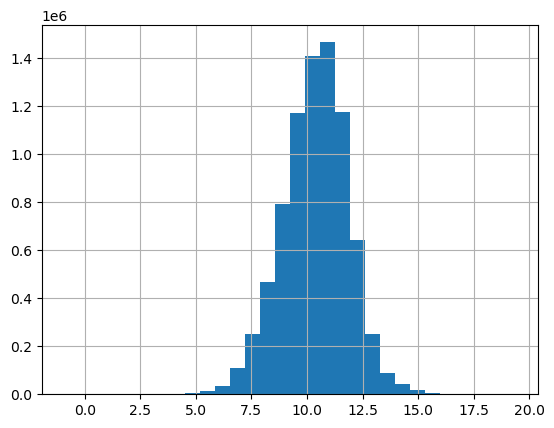

In [27]:
np.log(X_train['Tot_Mdcr_Pymt_Amt']).hist(bins=30)

In [14]:
df_2022 = enc_df(df_2022)

In [12]:
RESULT_DF = pd.DataFrame(columns=['formula','val_percentage','train_percentage','AIC','BIC','val_deviance','pseudo_R^2','abs_val_percentage'])
RESULT_DF

,formula,val_percentage,train_percentage,AIC,BIC,val_deviance,pseudo_R^2,abs_val_percentage


In [15]:
X_train.columns

Index(['Tot_Benes', 'Bene_Avg_Age', 'Bene_Avg_Risk_Scre', 'Tot_Risk', 'year',
       'Is_Covid', 'Tot_Mdcr_Pymt_Amt', 'Cd_I', 'Cd_O', 'Type_PrimaryCare',
       'Type_LabPathology', 'Type_Anesthesia', 'Type_OBGYN',
       'Type_SurgeryOther', 'Type_CardioVascularSurgery', 'Type_APP',
       'Type_Cardiology', 'Type_MedicalSpecialtyOther', 'Type_RehabTherapy',
       'Type_FacilitySupplierProgram', 'Type_OncologyHeme',
       'Type_RadiologyImaging', 'Type_AcuteCare', 'Type_BehavioralHealth',
       'Type_VisionHearing', 'Type_PharmacyNutrition', 'Type_UnknownOther',
       'Ind_Y', 'Ind_N', 'APP_Tot_Risk_2', 'APP_Tot_Risk_1', 'APP_Tot_Risk_0',
       'PrimaryCare_Tot_Risk_0', 'PrimaryCare_Tot_Risk_2',
       'PrimaryCare_Tot_Risk_1', 'MedicalSpecialtyOther_Tot_Risk_2',
       'MedicalSpecialtyOther_Tot_Risk_0', 'MedicalSpecialtyOther_Tot_Risk_1',
       'LabPathology_Tot_Risk_3', 'LabPathology_Tot_Risk_2',
       'LabPathology_Tot_Risk_0', 'LabPathology_Tot_Risk_1',
       'PharmacyNut

In [16]:
feature_cols = [c for c in X_train.columns.tolist() if c not in ['Tot_Benes','Tot_Risk','Tot_Mdcr_Pymt_Amt']]

# Null Model

In [17]:
MODEL_null_offset = smf.glm(
    formula="Tot_Mdcr_Pymt_Amt ~ 1",
    data=df_train,
    family=sm.families.Gamma(link=sm.families.links.Log()),
    offset=np.log(df_train["Tot_Benes"]),
).fit()

In [16]:
RESULT_DF.to_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_6.csv')

In [29]:
RESULT_DF = pd.read_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_6.csv').drop('Unnamed: 0',axis=1)
print(len("".join(RESULT_DF.sort_values('val_deviance').iat[0,0]).strip("[ ]'").replace("'",'').replace(" ",'').split(",")))

4


# Auto selection

In [19]:
def next_best_formula(result_df,col):
    if result_df.shape[0]==0:
        return 'Tot_Mdcr_Pymt_Amt ~'
    features = "".join(result_df.sort_values(col).iat[0,0]).strip("[ ]'").replace("'",'').replace(" ",'').split(",")
    formula = 'Tot_Mdcr_Pymt_Amt ~ '
    for x in features:
        formula+=f'{x}+'
    return formula[:-1]

def feature_selection(result_df,col,feature_cols):
    FORMULA = next_best_formula(result_df,col)
    for c in feature_cols:
        if c not in FORMULA:
            if c=='year':
                formula = FORMULA + '+cr(year,df=3)'
            else:
                formula = FORMULA + f'+{c}'
            MODEL = smf.glm(
                formula = formula,
                data = X_train,
                family = sm.families.Gamma(link=sm.families.links.Log()),
                offset = np.log(X_train['Tot_Benes'])
            ).fit()

            y_pred = MODEL.predict(X_val,offset=np.log(X_val['Tot_Benes']))

            val_p = sum(y_pred)/actual_total_y

            train_p = sum(MODEL.predict(X_train,offset=np.log(X_train['Tot_Benes'])))/sum(X_train['Tot_Mdcr_Pymt_Amt'])

            r2_dev = 1 - MODEL.deviance / MODEL_null_offset.deviance

            val_d = MODEL.model.family.deviance(X_val['Tot_Mdcr_Pymt_Amt'],y_pred,scale=MODEL.scale)

            temp = pd.DataFrame({
                'formula': [formula.replace('\n','').replace(' ','')[18:].split('+')],
                'val_percentage': [val_p],
                'train_percentage': [train_p],
                'AIC':[MODEL.aic],
                'BIC':[MODEL.bic_llf],
                'val_deviance': [val_d],
                'pseudo_R^2': [r2_dev],
                'abs_val_percentage':[abs(val_p-1)]
            })
            result_df = pd.concat([result_df,temp],axis=0)
    
    return result_df

In [31]:
RESULT_DF=pd.read_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_6.csv').drop('Unnamed: 0',axis=1)
RESULT_DF.sort_values('abs_val_percentage')

,formula,val_percentage,train_percentage,AIC,BIC,val_deviance,pseudo_R^2,abs_val_percentage
205,"['Type_RehabTherapy', 'Type_OncologyHeme', 'Ty...",1.123857,1.133248,2.320254e+08,2.320255e+08,18050.561305,0.120079,0.123857
160,"['Type_RehabTherapy', 'Type_OncologyHeme', 'Ty...",1.133205,1.135197,2.307175e+08,2.307176e+08,20094.348053,0.110416,0.133205
191,"['Type_RehabTherapy', 'Type_OncologyHeme', 'Ty...",1.144741,1.207718,2.278592e+08,2.278592e+08,23090.756410,0.145370,0.144741
193,"['Type_RehabTherapy', 'Type_OncologyHeme', 'Ty...",1.162928,1.207530,2.324319e+08,2.324320e+08,17750.389504,0.110828,0.162928
145,"['Type_RehabTherapy', 'Type_OncologyHeme', 'Ty...",1.163583,1.218508,2.265182e+08,2.265183e+08,26008.255901,0.131246,0.163583
...,...,...,...,...,...,...,...,...
99,"['Type_RehabTherapy', 'Type_OncologyHeme', 'cr...",1.462199,1.265914,2.293579e+08,2.293580e+08,24606.991749,0.075851,0.462199
51,"['Type_RehabTherapy', 'cr(year,df=3)']",1.481562,1.284652,2.278742e+08,2.278742e+08,28823.972452,0.021324,0.481562
4,[Cd_I],1.493401,1.427834,2.139931e+08,2.139931e+08,76004.642733,0.022870,0.493401
5,[Cd_O],1.493401,1.427834,2.139931e+08,2.139931e+08,76004.642733,0.022870,0.493401


In [21]:
def best_formula(result_df,col):
    features = "".join(result_df.sort_values(col).iat[0,0]).strip("[ ]'").replace("'",'').replace(" ",'').split(",")
    print(result_df.sort_values(col).reset_index(drop=True).loc[0,:])
    print(features)
    print(len(features))
    formula = 'Tot_Mdcr_Pymt_Amt ~ '
    for x in features:
        formula+=f'{x}+'
    return formula[:-1]

In [30]:
df = feature_selection(RESULT_DF,'val_deviance',feature_cols)
df.to_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_6.csv')
df.sort_values('val_deviance')

,formula,val_percentage,train_percentage,AIC,BIC,val_deviance,pseudo_R^2,abs_val_percentage
0,"[Type_RehabTherapy, Type_OncologyHeme, Type_Be...",1.194487,1.217176,2.339932e+08,2.339933e+08,15395.935445,0.130809,0.194487
0,"[Type_RehabTherapy, Type_OncologyHeme, Type_Be...",1.183107,1.210964,2.339386e+08,2.339387e+08,15726.002059,0.120602,0.183107
0,"[Type_RehabTherapy, Type_OncologyHeme, Type_Be...",1.183107,1.210964,2.339386e+08,2.339387e+08,15726.002059,0.120602,0.183107
0,"[Type_RehabTherapy, Type_OncologyHeme, Type_Be...",1.174787,1.199796,2.335812e+08,2.335812e+08,16232.239245,0.115673,0.174787
0,"[Type_RehabTherapy, Type_OncologyHeme, Type_Be...",1.184571,1.198488,2.326874e+08,2.326874e+08,16699.187377,0.121878,0.184571
...,...,...,...,...,...,...,...,...
102,"['Type_RehabTherapy', 'Type_OncologyHeme', 'Cd...",1.433863,1.360155,2.137768e+08,2.137768e+08,69022.531719,0.109108,0.433863
54,"['Type_RehabTherapy', 'Cd_O']",1.445319,1.373232,2.144398e+08,2.144398e+08,70533.042743,0.047524,0.445319
53,"['Type_RehabTherapy', 'Cd_I']",1.445319,1.373232,2.144398e+08,2.144398e+08,70533.042744,0.047524,0.445319
4,[Cd_I],1.493401,1.427834,2.139931e+08,2.139931e+08,76004.642733,0.022870,0.493401


In [32]:
RESULT_DF=pd.read_csv(f'{path}/Modeling/GLM_GAMMA_RESULTS_6.csv').drop('Unnamed: 0',axis=1)
print(len("".join(RESULT_DF.sort_values('val_deviance').iat[0,0]).strip("[ ]'").replace("'",'').replace(" ",'').split(",")))
RESULT_DF.sort_values('val_deviance').iat[0,0]

5


"['Type_RehabTherapy', 'Type_OncologyHeme', 'Type_BehavioralHealth', 'Type_SurgeryOther', 'MedicalSpecialtyOther_Tot_Risk_0']"

## Model_1 val_deviance

formula               ['Type_OncologyHeme', 'Type_RehabTherapy', 'Ty...
val_percentage                                                 0.929289
train_percentage                                               1.193305
AIC                                                     205263711.17146
BIC                                                    205263917.335456
val_deviance                                               10778.692009
pseudo_R^2                                                     0.165968
abs_val_percentage                                             0.070711
Name: 0, dtype: object
['Type_OncologyHeme', 'Type_RehabTherapy', 'Type_BehavioralHealth', 'PrimaryCare_Tot_Risk_1', 'MedicalSpecialtyOther_Tot_Risk_0', 'Type_SurgeryOther', 'APP_Tot_Risk_0', 'Type_CardioVascularSurgery', 'Type_VisionHearing', 'Type_Cardiology', 'MedicalSpecialtyOther_Tot_Risk_2', 'Is_Covid', 'Type_UnknownOther', 'Ind_N']
14
0.9292891893566689


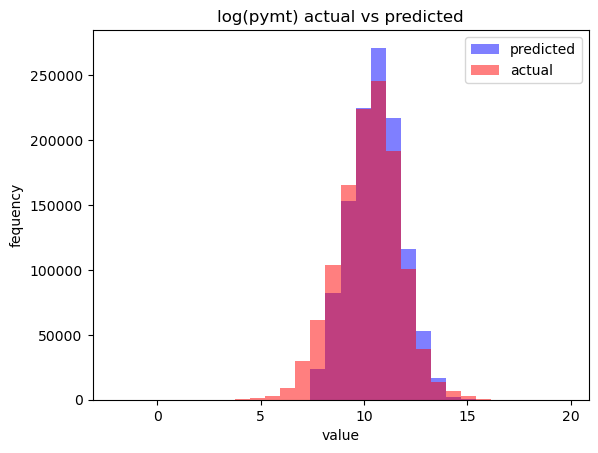

                 Generalized Linear Model Regression Results                  
Dep. Variable:      Tot_Mdcr_Pymt_Amt   No. Observations:              6880944
Model:                            GLM   Df Residuals:                  6880929
Model Family:                   Gamma   Df Model:                           14
Link Function:                    Log   Scale:                          87.967
Method:                          IRLS   Log-Likelihood:            -1.0263e+08
Date:                Mon, 09 Mar 2026   Deviance:                   7.0569e+06
Time:                        16:30:13   Pearson chi2:                 6.05e+08
No. Iterations:                    11   Pseudo R-squ. (CS):           0.002313
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [202]:
formula = best_formula(RESULT_DF,'val_deviance')

MODEL_1 = smf.glm(
                formula = formula,
                data = X_train,
                family = sm.families.Gamma(link=sm.families.links.Log()),
                offset = np.log(X_train['Tot_Benes'])
            ).fit()

y_pred = MODEL_1.predict(X_val,offset=np.log(X_val['Tot_Benes'].apply(lambda x:x if x!=0 else 1)))

print(sum(y_pred)/actual_total_y)

log_y_pred = np.log(y_pred.apply(lambda x:x if x!=0 else 1))
log_actual_y = np.log(actual_y.apply(lambda x:x if x!=0 else 1))

bins = np.histogram_bin_edges(np.concatenate([log_y_pred, log_actual_y]), bins=30)

plt.hist(log_y_pred, bins=bins, alpha=0.5, color="blue", label="predicted")
plt.hist(log_actual_y, bins=bins, alpha=0.5, color='red',label='actual')

plt.legend()
plt.xlabel('value')
plt.ylabel('fequency')
plt.title('log(pymt) actual vs predicted')
plt.show()

print(MODEL_1.summary())

In [205]:
summary_df = pd.DataFrame({
    "coef": MODEL_1.params,
    "p_value": MODEL_1.pvalues,
    # "std_err": MODEL_1.bse,
    # "z": MODEL_1.tvalues   # for GLM this is usually z-stat
})

summary_df = summary_df.sort_values("p_value")

print(summary_df)

                                      coef        p_value
Intercept                         5.540508   0.000000e+00
Type_OncologyHeme                 1.802172   0.000000e+00
Type_RehabTherapy                 0.837552   0.000000e+00
Type_BehavioralHealth             0.941895   0.000000e+00
Type_SurgeryOther                 0.573734   0.000000e+00
PrimaryCare_Tot_Risk_1            0.430877  2.080761e-244
MedicalSpecialtyOther_Tot_Risk_0  0.784028  6.410838e-208
Type_CardioVascularSurgery        1.260239  2.503370e-178
APP_Tot_Risk_0                    1.680311  6.032953e-132
Type_VisionHearing                0.117009   1.840284e-12
Is_Covid                         -0.062025   3.773219e-10
Type_Cardiology                   0.145409   4.688416e-10
MedicalSpecialtyOther_Tot_Risk_2 -0.092851   3.257678e-07
Ind_N                            -0.567094   1.534872e-05
Type_UnknownOther                 0.488291   2.243236e-02


In [ ]:
print('2023 ratio = ',sum(MODEL_1.predict(df_2022,offset=np.log(df_2022['Tot_Benes'])))/actual_total_2023)

2022 ratio =  1.1492354018061257
2023 ratio =  1.0370114682126228


## Model_2 abs_val_percentage

formula               ['Type_OncologyHeme', 'Type_RehabTherapy', 'Ty...
val_percentage                                                 1.000027
train_percentage                                               1.195867
AIC                                                    200913166.733746
BIC                                                     200913345.40921
val_deviance                                               13698.789218
pseudo_R^2                                                     0.224505
abs_val_percentage                                             0.000027
Name: 0, dtype: object
['Type_OncologyHeme', 'Type_RehabTherapy', 'Type_BehavioralHealth', 'PrimaryCare_Tot_Risk_1', 'MedicalSpecialtyOther_Tot_Risk_0', 'Type_SurgeryOther', 'APP_Tot_Risk_0', 'Type_CardioVascularSurgery', 'Type_VisionHearing', 'Type_Cardiology', 'MedicalSpecialtyOther_Tot_Risk_2', 'Bene_Avg_Risk_Scre']
12
1.0000274756242769


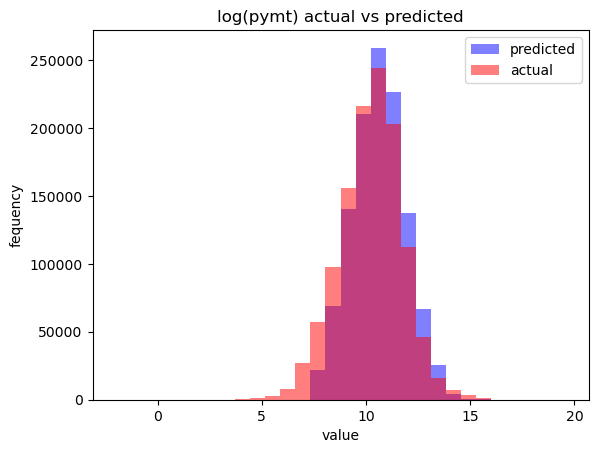

                 Generalized Linear Model Regression Results                  
Dep. Variable:      Tot_Mdcr_Pymt_Amt   No. Observations:              6880944
Model:                            GLM   Df Residuals:                  6880931
Model Family:                   Gamma   Df Model:                           12
Link Function:                    Log   Scale:                          62.938
Method:                          IRLS   Log-Likelihood:            -1.0046e+08
Date:                Mon, 09 Mar 2026   Deviance:                   6.5616e+06
Time:                        16:31:13   Pearson chi2:                 4.33e+08
No. Iterations:                    17   Pseudo R-squ. (CS):           0.004371
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [203]:
formula = best_formula(RESULT_DF,'abs_val_percentage')

MODEL_2 = smf.glm(
                formula = formula,
                data = X_train,
                family = sm.families.Gamma(link=sm.families.links.Log()),
                offset = np.log(X_train['Tot_Benes'])
            ).fit()

y_pred = MODEL_2.predict(X_val,offset=np.log(X_val['Tot_Benes'].apply(lambda x:x if x!=0 else 1)))

print(sum(y_pred)/actual_total_y)

log_y_pred = np.log(y_pred.apply(lambda x:x if x!=0 else 1))
log_actual_y = np.log(actual_y.apply(lambda x:x if x!=0 else 1))

bins = np.histogram_bin_edges(np.concatenate([log_y_pred, log_actual_y]), bins=30)

plt.hist(log_y_pred, bins=bins, alpha=0.5, color="blue", label="predicted")
plt.hist(log_actual_y, bins=bins, alpha=0.5, color='red',label='actual')

plt.legend()
plt.xlabel('value')
plt.ylabel('fequency')
plt.title('log(pymt) actual vs predicted')
plt.show()

print(MODEL_2.summary())

In [206]:
summary_df = pd.DataFrame({
    "coef": MODEL_2.params,
    "p_value": MODEL_2.pvalues,
    # "std_err": MODEL_1.bse,
    # "z": MODEL_1.tvalues   # for GLM this is usually z-stat
})

summary_df = summary_df.sort_values("p_value")

print(summary_df)

                                      coef        p_value
Intercept                         4.698405   0.000000e+00
Type_OncologyHeme                 1.801900   0.000000e+00
Type_RehabTherapy                 1.078604   0.000000e+00
Type_BehavioralHealth             1.114697   0.000000e+00
PrimaryCare_Tot_Risk_1            0.599287   0.000000e+00
MedicalSpecialtyOther_Tot_Risk_0  1.129737   0.000000e+00
Type_SurgeryOther                 0.689468   0.000000e+00
Bene_Avg_Risk_Scre                0.323575   0.000000e+00
APP_Tot_Risk_0                    1.813046  3.028945e-213
Type_CardioVascularSurgery        1.162248  1.795318e-210
Type_VisionHearing                0.317546  3.052815e-110
MedicalSpecialtyOther_Tot_Risk_2  0.127795   4.572791e-16
Type_Cardiology                   0.154398   5.673786e-15


In [ ]:
print('2023 ratio = ',sum(MODEL_2.predict(df_2022,offset=np.log(df_2022['Tot_Benes'])))/actual_total_2023)

2022 ratio =  1.0905780716050535
2023 ratio =  0.9817959090654814


## Model 3

In [207]:
def top_x_perc_mask(df,col,x):
    cutoff = df[col].quantile(x)
    return df[col]<=cutoff

In [222]:
x = 0.25
mask_dev = top_x_perc_mask(RESULT_DF,'val_deviance',x)
mask_per = top_x_perc_mask(RESULT_DF,'abs_val_percentage',x)

print("".join(RESULT_DF[mask_dev&mask_per].sort_values('val_deviance').iat[0,0]).strip("[ ]'").replace("'",'').replace(" ",'').split(","))
print(len("".join(RESULT_DF[mask_dev&mask_per].sort_values('val_deviance').iat[0,0]).strip("[ ]'").replace("'",'').replace(" ",'').split(",")))
RESULT_DF[mask_dev&mask_per]

['Type_OncologyHeme', 'Type_RehabTherapy', 'Type_BehavioralHealth', 'PrimaryCare_Tot_Risk_1', 'MedicalSpecialtyOther_Tot_Risk_0', 'Type_SurgeryOther', 'APP_Tot_Risk_0', 'Type_CardioVascularSurgery', 'Type_VisionHearing', 'Type_Cardiology', 'MedicalSpecialtyOther_Tot_Risk_2', 'Type_Anesthesia']
12


,formula,val_percentage,train_percentage,AIC,BIC,val_deviance,pseudo_R^2,abs_val_percentage
492,"['Type_OncologyHeme', 'Type_RehabTherapy', 'Ty...",0.9894,1.203287,2.042350e+08,2.042352e+08,11764.048182,0.169088,0.0106


formula               ['Type_OncologyHeme', 'Type_RehabTherapy', 'Ty...
val_percentage                                                   0.9894
train_percentage                                               1.203287
AIC                                                    204235021.264063
BIC                                                    204235199.939526
val_deviance                                               11764.048182
pseudo_R^2                                                     0.169088
abs_val_percentage                                               0.0106
Name: 0, dtype: object
['Type_OncologyHeme', 'Type_RehabTherapy', 'Type_BehavioralHealth', 'PrimaryCare_Tot_Risk_1', 'MedicalSpecialtyOther_Tot_Risk_0', 'Type_SurgeryOther', 'APP_Tot_Risk_0', 'Type_CardioVascularSurgery', 'Type_VisionHearing', 'Type_Cardiology', 'MedicalSpecialtyOther_Tot_Risk_2', 'Type_Anesthesia']
12
0.9893997683356381


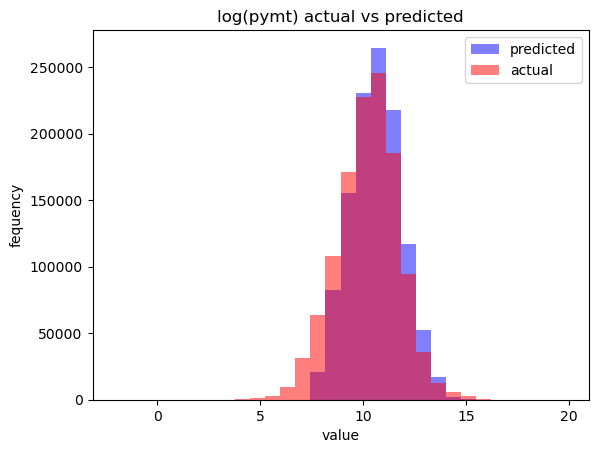

                 Generalized Linear Model Regression Results                  
Dep. Variable:      Tot_Mdcr_Pymt_Amt   No. Observations:              6880944
Model:                            GLM   Df Residuals:                  6880931
Model Family:                   Gamma   Df Model:                           12
Link Function:                    Log   Scale:                          81.300
Method:                          IRLS   Log-Likelihood:            -1.0212e+08
Date:                Mon, 09 Mar 2026   Deviance:                   7.0305e+06
Time:                        16:48:11   Pearson chi2:                 5.59e+08
No. Iterations:                     8   Pseudo R-squ. (CS):           0.002550
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [229]:
formula = best_formula(RESULT_DF[mask_dev&mask_per],'abs_val_percentage')

MODEL_3 = smf.glm(
                formula = formula,
                data = X_train,
                family = sm.families.Gamma(link=sm.families.links.Log()),
                offset = np.log(X_train['Tot_Benes'])
            ).fit()

y_pred = MODEL_3.predict(X_val,offset=np.log(X_val['Tot_Benes'].apply(lambda x:x if x!=0 else 1)))

print(sum(y_pred)/actual_total_y)

log_y_pred = np.log(y_pred.apply(lambda x:x if x!=0 else 1))
log_actual_y = np.log(actual_y.apply(lambda x:x if x!=0 else 1))

bins = np.histogram_bin_edges(np.concatenate([log_y_pred, log_actual_y]), bins=30)

plt.hist(log_y_pred, bins=bins, alpha=0.5, color="blue", label="predicted")
plt.hist(log_actual_y, bins=bins, alpha=0.5, color='red',label='actual')

plt.legend()
plt.xlabel('value')
plt.ylabel('fequency')
plt.title('log(pymt) actual vs predicted')
plt.show()

print(MODEL_3.summary())

In [ ]:
print('2023 ratio = ',sum(MODEL_3.predict(df_2022,offset=np.log(df_2022['Tot_Benes'])))/actual_total_2023)

2022 ratio =  1.1514846024856404
2023 ratio =  1.0381639191892829


## It looks like Model_2 wins in terms of predicting the total pymt